In [6]:
import pandas as pd
import numpy as np
import os
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/raw/budget_vs_actuals.csv", index=False)
df.to_csv("../data/processed/budget_variance_cleaned.csv", index=False)
print("Files saved!")
np.random.seed(42)

months = pd.period_range(start="2021-01", periods=36, freq="M")
products = ["Technology", "Furniture", "Office Supplies"]
regions = ["East", "West", "Central", "South"]

rows = []

for month in months:
    for product in products:
        for region in regions:
            # Base budget
            budget_revenue = np.random.uniform(20000, 80000)
            budget_cost = budget_revenue * np.random.uniform(0.6, 0.8)
            budget_profit = budget_revenue - budget_cost

            # Actuals with variance (+/- 20%)
            variance_factor = np.random.uniform(0.8, 1.2)
            actual_revenue = budget_revenue * variance_factor
            actual_cost = actual_revenue * np.random.uniform(0.6, 0.8)
            actual_profit = actual_revenue - actual_cost

            rows.append({
                "year_month": str(month),
                "product": product,
                "region": region,
                "budget_revenue": round(budget_revenue, 2),
                "budget_cost": round(budget_cost, 2),
                "budget_profit": round(budget_profit, 2),
                "actual_revenue": round(actual_revenue, 2),
                "actual_cost": round(actual_cost, 2),
                "actual_profit": round(actual_profit, 2)
            })

df = pd.DataFrame(rows)

# Calculate variances
df["revenue_variance"] = (df["actual_revenue"] - df["budget_revenue"]).round(2)
df["profit_variance"] = (df["actual_profit"] - df["budget_profit"]).round(2)
df["revenue_variance_pct"] = ((df["revenue_variance"] / df["budget_revenue"]) * 100).round(2)
df["variance_type"] = df["revenue_variance"].apply(lambda x: "Favorable" if x >= 0 else "Unfavorable")

print(" ", df.shape)
df.head()

Files saved!
  (432, 13)


,year_month,product,region,budget_revenue,budget_cost,budget_profit,actual_revenue,actual_cost,actual_profit,revenue_variance,profit_variance,revenue_variance_pct,variance_type
0,2021-01,Technology,East,42472.41,33559.27,8913.14,46413.74,33405.44,13008.30,3941.33,4095.16,9.28,Favorable
1,2021-01,Technology,West,29361.12,18532.71,10828.41,24171.05,18689.91,5481.14,-5190.07,-5347.27,-17.68,Unfavorable
2,2021-01,Technology,Central,56066.90,41580.03,14486.87,45315.16,35979.42,9335.74,-10751.74,-5151.13,-19.18,Unfavorable
3,2021-01,Technology,South,69946.56,44938.41,25008.15,61044.46,38865.84,22178.62,-8902.10,-2829.53,-12.73,Unfavorable
4,2021-01,Furniture,East,38254.53,26967.58,11286.95,37213.17,24495.41,12717.76,-1041.36,1430.81,-2.72,Unfavorable


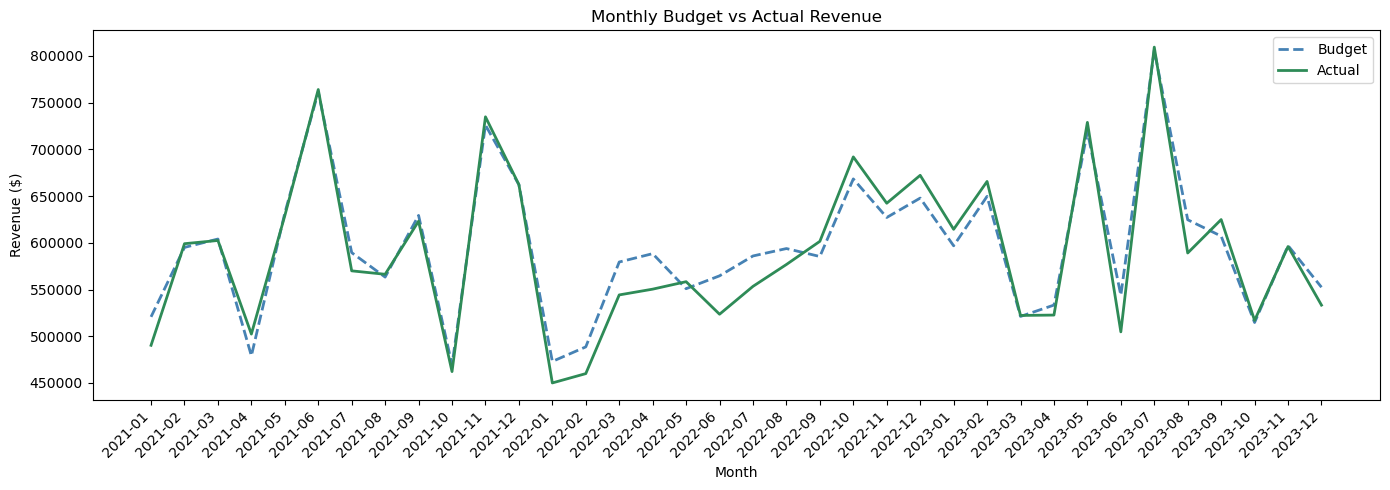

In [8]:
monthly = df.groupby("year_month")[["budget_revenue", "actual_revenue", "revenue_variance"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["year_month"], monthly["budget_revenue"], label="Budget", color="steelblue", linewidth=2, linestyle="--")
ax.plot(monthly["year_month"], monthly["actual_revenue"], label="Actual", color="seagreen", linewidth=2)
ax.set(title="Monthly Budget vs Actual Revenue", xlabel="Month", ylabel="Revenue ($)")
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/budget_vs_actual_revenue.png")
plt.show()

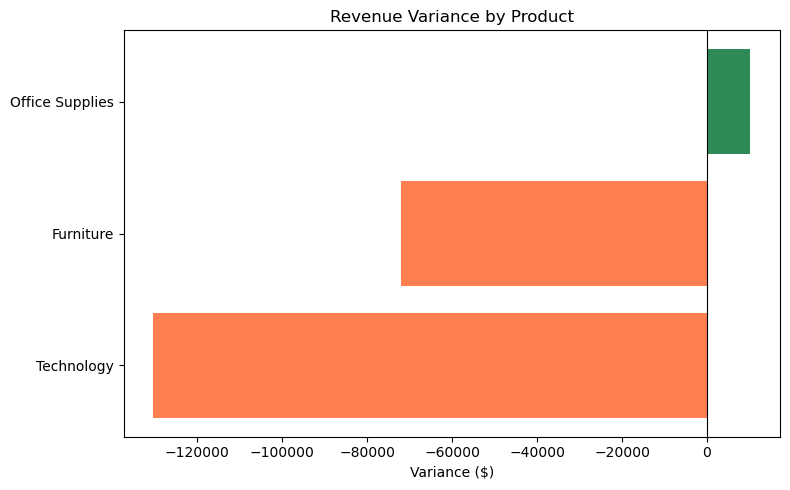

In [9]:
product = df.groupby("product")["revenue_variance"].sum().reset_index().sort_values("revenue_variance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(product["product"], product["revenue_variance"], color=["coral" if v < 0 else "seagreen" for v in product["revenue_variance"]])
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set(title="Revenue Variance by Product", xlabel="Variance ($)")
plt.tight_layout()
plt.savefig("../reports/variance_by_product.png")
plt.show()

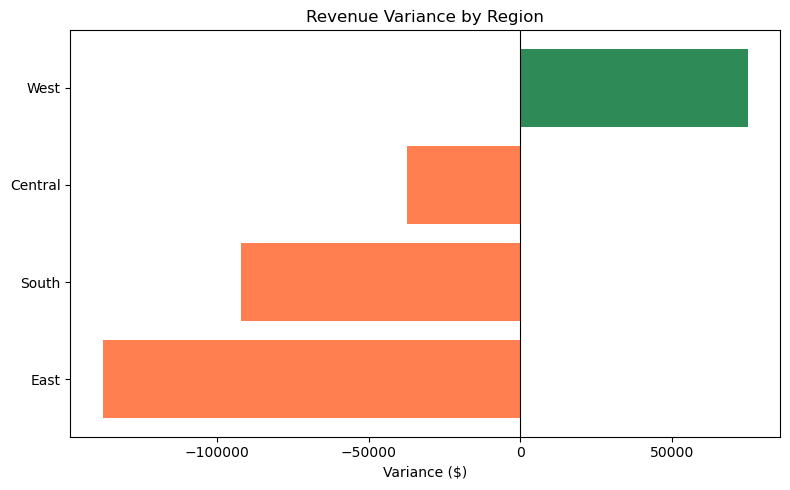

In [12]:
region = df.groupby("region")["revenue_variance"].sum().reset_index().sort_values("revenue_variance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(region["region"], region["revenue_variance"], color=["coral" if v < 0 else "seagreen" for v in region["revenue_variance"]])
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set(title="Revenue Variance by Region", xlabel="Variance ($)")
plt.tight_layout()
plt.savefig("../reports/variance_by_region.png")
plt.show()

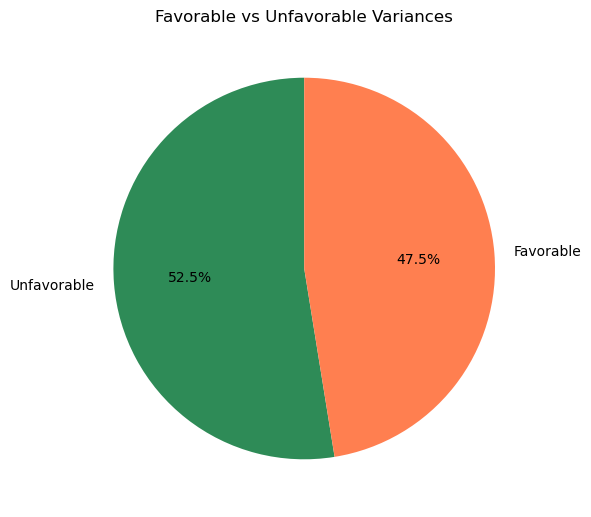

In [13]:
variance_summary = df["variance_type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(variance_summary, labels=variance_summary.index, colors=["seagreen", "coral"], autopct="%1.1f%%", startangle=90)
ax.set_title("Favorable vs Unfavorable Variances")
plt.tight_layout()
plt.savefig("../reports/favorable_vs_unfavorable.png")
plt.show()

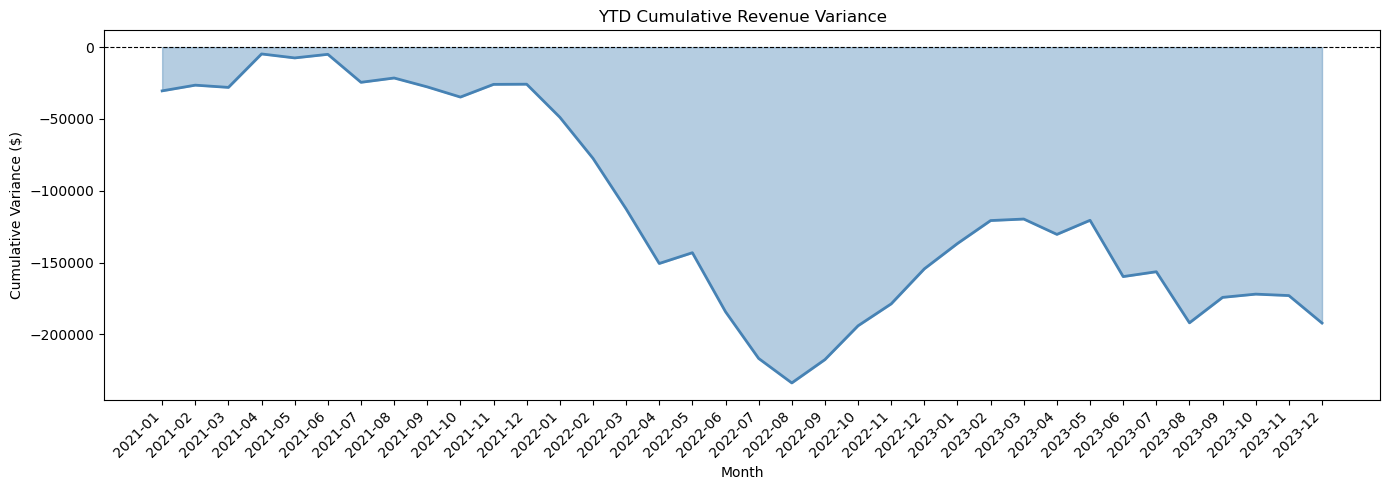

In [14]:
monthly["ytd_variance"] = monthly["revenue_variance"].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly["year_month"], monthly["ytd_variance"], color="steelblue", alpha=0.4)
ax.plot(monthly["year_month"], monthly["ytd_variance"], color="steelblue", linewidth=2)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set(title="YTD Cumulative Revenue Variance", xlabel="Month", ylabel="Cumulative Variance ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/ytd_cumulative_variance.png")
plt.show()